# 02 — Classificação do Fashion-MNIST com uma CNN

Treinamos uma **Rede Neural Convolucional (CNN)** no estilo *LeNet* para classificar
as peças de roupa. Uma CNN aprende **filtros** que detectam padrões locais (bordas,
texturas) e os combina em representações cada vez mais abstratas — muito mais
eficiente para imagens do que uma rede totalmente conectada.

**Metodologia (rígida quanto a vazamento de dados):**
- Treino (60k) dividido em **50k treino + 10k validação**.
- **Data augmentation leve** (recorte + espelhamento) aplicada *só no treino*;
  validação e teste ficam sem augmentation, para uma avaliação honesta.
- A validação guia o treino e a escolha do melhor modelo.
- O **teste (10k) é usado UMA única vez**, no final — nunca para ajustar nada.

> A matemática de cada operação está documentada em `docs/`.

In [1]:
# ── Setup — funciona igual no seu PC e no Google Colab ───────────────────────
# Ajuste REPO_URL após publicar o projeto no GitHub (ver README).
import sys, os, subprocess
from pathlib import Path

REPO_URL = "https://github.com/4rth-g/fashion-mnist-fundamentos-ia.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # No Colab não há o repositório: clonamos para ter o código de src/ e as pastas.
    if not Path("fashion-mnist-fundamentos-ia").exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)
    os.chdir("fashion-mnist-fundamentos-ia")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "seaborn"], check=True)

# Torna o pacote src/ importável (local: rodando de notebooks/; Colab: da raiz).
_root = Path.cwd()
_src = _root / "src" if (_root / "src").exists() else _root.parent / "src"
sys.path.insert(0, str(_src))
print("src/ em:", _src)

src/ em: /home/arthurg/Projetos_Dev/fashion-mnist-fundamentos-ia/src


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from utils import (seed_everything, get_device, make_dataloaders,
                   MODELS_DIR, FIGURES_DIR)

seed_everything()
device = get_device()

# DataLoaders com split treino/val/teste correto e augmentation leve só no treino.
train_loader, val_loader, test_loader = make_dataloaders(batch_size=128, device=device)
print(f"Batches — treino: {len(train_loader)} | val: {len(val_loader)} | teste: {len(test_loader)}")

## A arquitetura, operação por operação

| Etapa | Operação | Entrada → Saída |
|---|---|---|
| 1 | `Conv2d(1→32, 3×3, pad=1)` + ReLU | `1×28×28` → `32×28×28` |
| 2 | `MaxPool2d(2)` | `32×28×28` → `32×14×14` |
| 3 | `Conv2d(32→64, 3×3, pad=1)` + ReLU | `32×14×14` → `64×14×14` |
| 4 | `MaxPool2d(2)` | `64×14×14` → `64×7×7` |
| 5 | `Flatten` | `64×7×7` → `3136` |
| 6 | `Linear(3136→128)` + ReLU + `Dropout(0.5)` | `3136` → `128` |
| 7 | `Linear(128→10)` | `128` → `10` (logits) |

Cada operação está escrita **explicitamente** no `forward` abaixo, com o formato do
tensor comentado em cada passo. A explicação matemática (convolução, pooling,
ReLU, softmax, entropia cruzada) está em `docs/`.

In [3]:
class CNN(nn.Module):
    """CNN estilo LeNet: 1×28×28 → 10 classes."""

    def __init__(self):
        super().__init__()
        # --- Bloco convolucional (extração de características) ---
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu  = nn.ReLU()
        # --- Bloco totalmente conectado (classificação) ---
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):                 # x: [N, 1, 28, 28]
        x = self.relu(self.conv1(x))      # convolução 1 + ReLU  -> [N, 32, 28, 28]
        x = self.pool(x)                  # sub-amostragem       -> [N, 32, 14, 14]
        x = self.relu(self.conv2(x))      # convolução 2 + ReLU  -> [N, 64, 14, 14]
        x = self.pool(x)                  # sub-amostragem       -> [N, 64, 7, 7]
        x = self.flatten(x)               # achata               -> [N, 3136]
        x = self.relu(self.fc1(x))        # camada densa + ReLU  -> [N, 128]
        x = self.dropout(x)               # regularização (só no treino)
        x = self.fc2(x)                   # camada de saída      -> [N, 10] (logits)
        return x


model = CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParâmetros treináveis: {n_params:,}")

# Teste de sanidade: um lote falso deve sair com formato [4, 10].
dummy = torch.randn(4, 1, 28, 28, device=device)
print(f"Forward de teste: {tuple(model(dummy).shape)}  (esperado: (4, 10))")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Parâmetros treináveis: 421,642
Forward de teste: (4, 10)  (esperado: (4, 10))


## Treino

- **Função de perda:** entropia cruzada (`CrossEntropyLoss`) — padrão para
  classificação multiclasse. Ela já aplica *softmax* internamente, por isso a rede
  devolve *logits* (sem softmax no `forward`).
- **Otimizador:** Adam, `lr = 1e-3`.
- A cada época medimos perda/acurácia em treino e **validação**; guardamos os pesos
  da **melhor época segundo a validação** (`cnn_fashion_mnist.pt`).

In [4]:
def run_epoch(model, loader, criterion, optimizer=None):
    """Roda uma época. Se `optimizer` for dado, treina; senão, apenas avalia."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if is_train:
                optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            n += images.size(0)

    return total_loss / n, correct / n

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_path = MODELS_DIR / "cnn_fashion_mnist.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_loader, criterion)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss);   history["val_acc"].append(vl_acc)

    flag = ""
    if vl_acc > best_val_acc:                 # guarda o melhor modelo (pela validação)
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_path)
        flag = "  <- melhor até agora (salvo)"

    print(f"Época {epoch:2d}/{EPOCHS} | "
          f"treino: loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val: loss {vl_loss:.4f} acc {vl_acc:.4f}{flag}")

print(f"\nMelhor acurácia de validação: {best_val_acc:.4f}  (pesos em {best_path.name})")

Época  1/10 | treino: loss 0.5948 acc 0.7839 | val: loss 0.3837 acc 0.8597  <- melhor até agora (salvo)
Época  2/10 | treino: loss 0.3821 acc 0.8622 | val: loss 0.3112 acc 0.8860  <- melhor até agora (salvo)
Época  3/10 | treino: loss 0.3315 acc 0.8812 | val: loss 0.2804 acc 0.8979  <- melhor até agora (salvo)
Época  4/10 | treino: loss 0.2974 acc 0.8940 | val: loss 0.2614 acc 0.9049  <- melhor até agora (salvo)
Época  5/10 | treino: loss 0.2687 acc 0.9036 | val: loss 0.2523 acc 0.9064  <- melhor até agora (salvo)
Época  6/10 | treino: loss 0.2503 acc 0.9103 | val: loss 0.2458 acc 0.9122  <- melhor até agora (salvo)
Época  7/10 | treino: loss 0.2349 acc 0.9152 | val: loss 0.2328 acc 0.9156  <- melhor até agora (salvo)
Época  8/10 | treino: loss 0.2156 acc 0.9205 | val: loss 0.2234 acc 0.9198  <- melhor até agora (salvo)
Época  9/10 | treino: loss 0.2067 acc 0.9244 | val: loss 0.2210 acc 0.9197
Época 10/10 | treino: loss 0.1909 acc 0.9310 | val: loss 0.2287 acc 0.9192

Melhor acurácia d

## Curvas de aprendizado

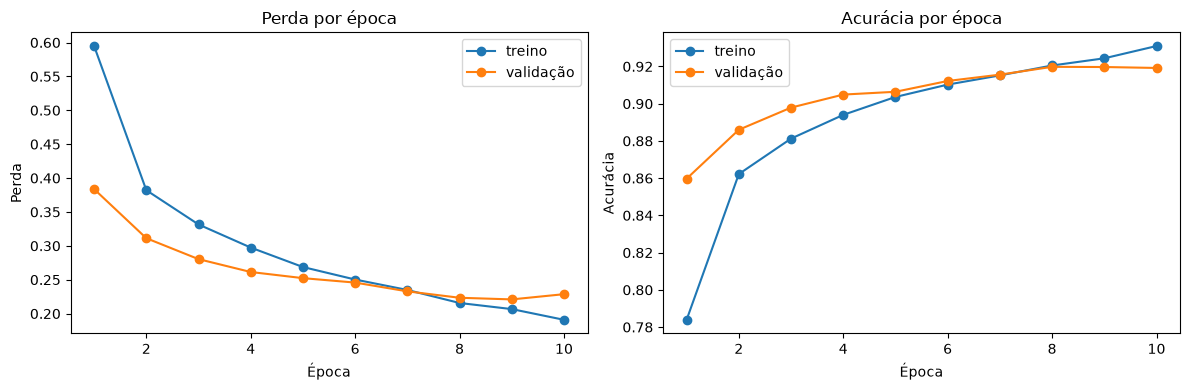

In [6]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], "o-", label="treino")
ax1.plot(epochs, history["val_loss"], "o-", label="validação")
ax1.set(title="Perda por época", xlabel="Época", ylabel="Perda"); ax1.legend()

ax2.plot(epochs, history["train_acc"], "o-", label="treino")
ax2.plot(epochs, history["val_acc"], "o-", label="validação")
ax2.set(title="Acurácia por época", xlabel="Época", ylabel="Acurácia"); ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "curvas_aprendizado.png", dpi=120)
plt.show()

## Avaliação final no conjunto de TESTE (uma única vez)

Só agora, com o modelo já escolhido pela validação, tocamos no conjunto de teste.
Isso garante que a acurácia reportada seja uma **estimativa honesta** do desempenho
em dados nunca vistos.

In [ ]:
import json
from datetime import datetime

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from utils import CLASS_NAMES, RESULTS_DIR

# Recarrega os melhores pesos (a melhor época segundo a validação).
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(device)).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(labels)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_acc = (all_preds == all_labels).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Acurácia no TESTE: {test_acc:.4f} | F1 macro: {macro_f1:.4f}\n")
print(classification_report(all_labels, all_preds, digits=4, target_names=CLASS_NAMES))

# Persiste as métricas para auditoria e reprodutibilidade (results/metrics.json).
metrics = {
    "test_accuracy": float(test_acc),
    "macro_f1": float(macro_f1),
    "best_val_accuracy": float(best_val_acc),
    "epochs": EPOCHS,
    "per_class": classification_report(all_labels, all_preds,
                                       target_names=CLASS_NAMES, output_dict=True),
    "gerado_em": datetime.now().isoformat(timespec="seconds"),
}
with open(RESULTS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print(f"\nMétricas salvas em {RESULTS_DIR / 'metrics.json'}")

## Matriz de confusão

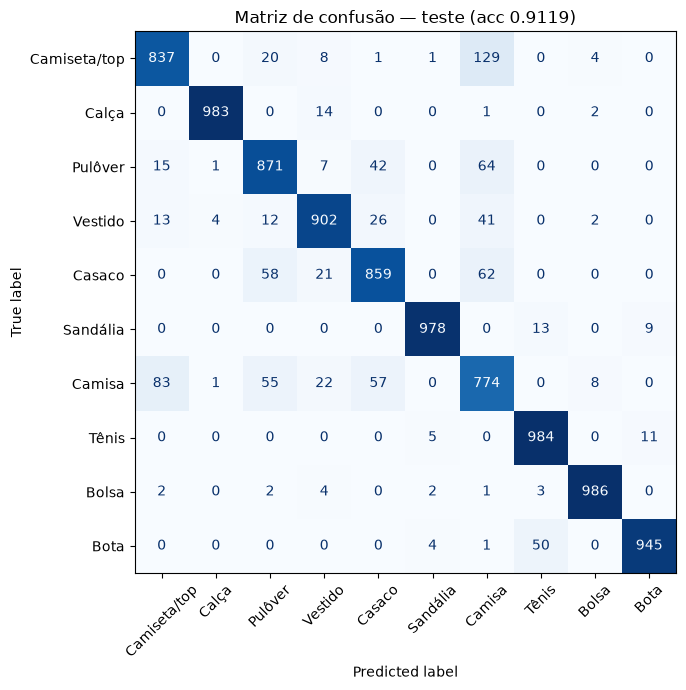

In [8]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Matriz de confusão — teste (acc {test_acc:.4f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "matriz_confusao.png", dpi=120)
plt.show()

## Alguns erros do modelo

Olhar os erros ajuda a entender as limitações — muitos são peças genuinamente
ambíguas (uma camisa que parece camiseta, um pulôver que parece casaco).

In [ ]:
errors = np.where(all_preds != all_labels)[0][:24]
# Recarrega o teste sem normalização só para exibir as imagens de forma legível.
from utils import load_fashion_mnist, CLASS_NAMES
_, test_vis = load_fashion_mnist(normalize=False)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for ax, idx in zip(axes.flat, errors):
    ax.imshow(test_vis[idx][0].squeeze(), cmap="gray")
    ax.set_title(f"pred: {CLASS_NAMES[all_preds[idx]]}\nreal: {CLASS_NAMES[all_labels[idx]]}",
                 color="red", fontsize=8)
    ax.axis("off")
fig.suptitle("Exemplos classificados incorretamente", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "erros_classificacao.png", dpi=120)
plt.show()

## Conclusão

A CNN atinge cerca de **90–93% de acurácia no teste** — bem abaixo dos ~99% do MNIST
original, o que mostra por que o Fashion-MNIST é um benchmark mais honesto. Pontos-chave:

- **Convolução + pooling** exploram a estrutura espacial da imagem, superando de
  longe uma rede totalmente conectada.
- A **separação treino/validação/teste** garante que o número reportado seja honesto.
- Os erros restantes concentram-se em categorias visualmente parecidas
  (Camisa × Camiseta/top × Pulôver × Casaco).